# Data Preprocessing for Harry Potter Passage Retrieval

This notebook demonstrates the process of downloading and preprocessing the text of the first Harry Potter book for passage retrieval tasks.

Steps covered:
1. Download the Harry Potter text
2. Clean and preprocess the text
3. Divide the text into manageable chunks
4. Save the chunks for later use

## Setup

First, let's import the necessary libraries and modules.

In [1]:
import sys
import os

# Add the src directory to the path so we can import our modules
sys.path.append('../src')

from preprocessing import (
    download_harry_potter_text,
    save_text_to_file,
    preprocess_text,
    chunk_text,
    save_chunks,
    load_chunks
)

[nltk_data] Downloading package punkt_tab to /home/user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Download the Harry Potter Text

We'll download the text of the first Harry Potter book from a public source.

In [2]:
# Create data directory if it doesn't exist
os.makedirs('../data', exist_ok=True)
url = "https://raw.githubusercontent.com/amephraim/nlp/master/texts/J.%20K.%20Rowling%20-%20Harry%20Potter%201%20-%20Sorcerer%27s%20Stone.txt"
# Download the Harry Potter text
book_path = download_harry_potter_text(url)
save_text_to_file(book_path, "../data/harry_potter_book1.txt")

Text saved to ../data/harry_potter_book1.txt


Let's take a look at the beginning of the text to understand its format.

In [3]:
# Read the first 1000 characters of the book

text_sample = book_path[:1000]

print(text_sample)

Harry Potter and the Sorcerer's Stone


CHAPTER ONE

THE BOY WHO LIVED

Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say
that they were perfectly normal, thank you very much. They were the last
people you'd expect to be involved in anything strange or mysterious,
because they just didn't hold with such nonsense.

Mr. Dursley was the director of a firm called Grunnings, which made
drills. He was a big, beefy man with hardly any neck, although he did
have a very large mustache. Mrs. Dursley was thin and blonde and had
nearly twice the usual amount of neck, which came in very useful as she
spent so much of her time craning over garden fences, spying on the
neighbors. The Dursleys had a small son called Dudley and in their
opinion there was no finer boy anywhere.

The Dursleys had everything they wanted, but they also had a secret, and
their greatest fear was that somebody would discover it. They didn't
think they could bear it if anyone found out about the Potters. Mr

## 2. Preprocess the Text

Now we'll clean and preprocess the text to prepare it for chunking.

In [4]:
# Preprocess the text
preprocessed_text = preprocess_text(book_path)

# Print the first 1000 characters of the preprocessed text
print(preprocessed_text[:1000])

Harry Potter and the Sorcerer's Stone Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you'd expect to be involved in anything strange or mysterious, because they just didn't hold with such nonsense. Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors. The Dursleys had a small son called Dudley and in their opinion there was no finer boy anywhere. The Dursleys had everything they wanted, but they also had a secret, and their greatest fear was that somebody would discover it. They didn't think they could bear it if anyone found out about the Potters. Mrs. Potter was Mrs. Dursley's sister,

## 3. Divide the Text into Chunks

We'll divide the text into chunks of approximately 500 characters each, trying to break at sentence boundaries when possible.

In [5]:
# Chunk the text


chunks = chunk_text(preprocessed_text, chunk_size=500)

print(f"Created {len(chunks)} chunks")

# Print the first 3 chunks
for i, chunk in enumerate(chunks[:3]):
    print(f"\nChunk {i+1}:")

Created 972 chunks

Chunk 1:

Chunk 2:

Chunk 3:


## 4. Save the Chunks for Later Use

We'll save the chunks to a JSON file for use in later notebooks.

In [6]:
# Save the chunks
chunks_path='../data/text_chunks.json'
save_chunks(chunks, chunks_path)

Text chunks saved to ../data/text_chunks.json


## 5. Verify the Saved Chunks

Let's load the chunks back from the JSON file to verify they were saved correctly.

In [7]:
# Load the chunks
loaded_chunks = load_chunks(chunks_path)

print(f"Loaded {len(loaded_chunks)} chunks")

# Verify the first chunk matches
print("\nFirst chunk from original:")
print(chunks[0])

print("\nFirst chunk from loaded:")
print(loaded_chunks[0])

# Check if they match
print(f"\nChunks match: {chunks[0] == loaded_chunks[0]}")

Loaded 972 chunks

First chunk from original:
Harry Potter and the Sorcerer's Stone Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you'd expect to be involved in anything strange or mysterious, because they just didn't hold with such nonsense. Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache.

First chunk from loaded:
Harry Potter and the Sorcerer's Stone Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you'd expect to be involved in anything strange or mysterious, because they just didn't hold with such nonsense. Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large must

## 6. Analyze Chunk Statistics

Let's analyze some statistics about our chunks to ensure they're appropriate for our retrieval tasks.

Average chunk length: 447.53 characters
Minimum chunk length: 116 characters
Maximum chunk length: 1071 characters
Standard deviation: 56.65 characters


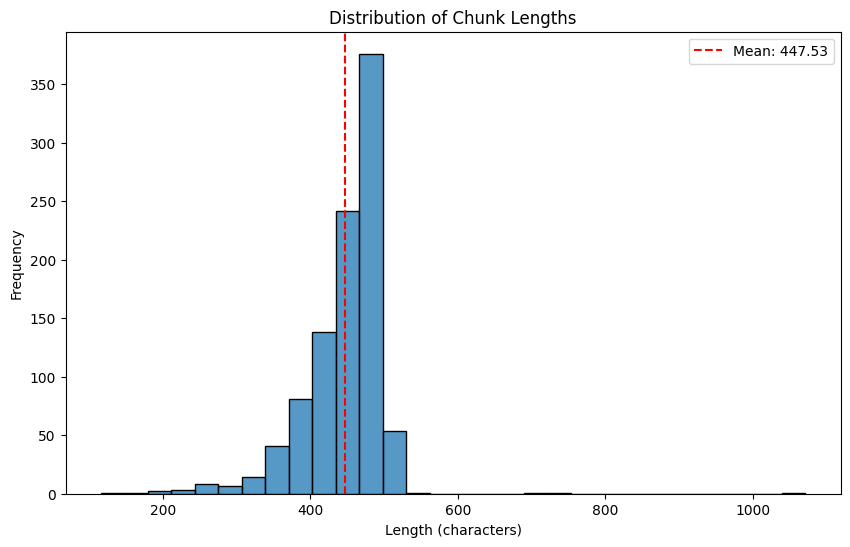

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate chunk lengths
chunk_lengths = [len(chunk) for chunk in chunks]

# Calculate statistics
avg_length = np.mean(chunk_lengths)
min_length = np.min(chunk_lengths)
max_length = np.max(chunk_lengths)
std_length = np.std(chunk_lengths)

print(f"Average chunk length: {avg_length:.2f} characters")
print(f"Minimum chunk length: {min_length} characters")
print(f"Maximum chunk length: {max_length} characters")
print(f"Standard deviation: {std_length:.2f} characters")

# Plot histogram of chunk lengths
plt.figure(figsize=(10, 6))
sns.histplot(chunk_lengths, bins=30)
plt.axvline(x=avg_length, color='r', linestyle='--', label=f'Mean: {avg_length:.2f}')
plt.title('Distribution of Chunk Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Summary

In this notebook, we've:
1. Downloaded the text of the first Harry Potter book
2. Preprocessed the text to clean it and prepare it for chunking
3. Divided the text into manageable chunks
4. Saved the chunks for later use
5. Verified the saved chunks
6. Analyzed statistics about our chunks

These chunks will be used in the subsequent notebooks for TF-IDF retrieval and semantic search.